# 

In [1]:
# # -----------------------------
# # 1) Load CSVs
# # -----------------------------
# train_df = pd.read_csv("label_pool.csv")


# FEATURES = [c for c in train_df.columns if c != "Label"]

In [1]:
# ============================================================
# AS-SRDT (SSRDT-Sinkhorn + Anomaly Score Supervision) — PyTorch
# FULL-PAIRS Intermediate Generation + KNN Filtering (paper-style)
# + ADD: Score Supervision Consistency Loss (SmoothL1)
# + Keep: Model selection by BEST Binary F1 (anomaly=1) on VAL
#
# Required CSVs:
#   - label_pool.csv
#   - val_labeled_40.csv
#   - test_labeled_60.csv
# ============================================================

import random
from copy import deepcopy
from collections import Counter
from contextlib import contextmanager

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
)
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
)
import time

t0 = time.perf_counter()

# -----------------------------
# 0) Reproducibility & device
# -----------------------------
mpl.rcParams["axes.formatter.useoffset"] = False
mpl.rcParams["axes.formatter.use_locale"] = False
mpl.rcParams["axes.formatter.use_mathtext"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# Preserve RNG state so validation computations won't affect training
# =========================
@contextmanager
def preserve_rng_state():
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_cpu_state = torch.get_rng_state()
    if torch.cuda.is_available():
        torch_cuda_state = torch.cuda.get_rng_state_all()
    else:
        torch_cuda_state = None
    try:
        yield
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.set_rng_state(torch_cpu_state)
        if torch_cuda_state is not None:
            torch.cuda.set_rng_state_all(torch_cuda_state)

# -----------------------------
# 1) Load CSVs
# -----------------------------
train_df = pd.read_csv("label_pool.csv")
val_df   = pd.read_csv("val_labeled_40.csv")
test_df  = pd.read_csv("test_labeled_60.csv")
# test_df  = pd.read_csv("test_labeled_60.csv")
FEATURES = [c for c in train_df.columns if c != "Label"]

X_train, y_train = train_df[FEATURES].copy(), train_df["Label"].copy()
X_val,   y_val   = val_df[FEATURES].copy(),   val_df["Label"].copy()
X_test,  y_test  = test_df[FEATURES].copy(),  test_df["Label"].copy()

print("Train size (before limit):", len(y_train),
      "| Val size:", len(y_val),
      "| Test size:", len(y_test))
print("Label counts (before limit) - Train:", Counter(y_train),
      "| Val:", Counter(y_val),
      "| Test:", Counter(y_test))

# -----------------------------
# 1b) Limit train to 800 normal + 9 anomaly
# -----------------------------
y_train_np_full = y_train.to_numpy().astype(int)
idx_all  = np.arange(len(y_train_np_full))
idx_norm = idx_all[y_train_np_full == 0]
idx_anom = idx_all[y_train_np_full == 1]

n_norm_target = 800
n_anom_target = 9

if len(idx_norm) < n_norm_target:
    print(f"[WARN] Train normal only {len(idx_norm)} < 800. Use {len(idx_norm)}.")
    n_norm_target = len(idx_norm)
if len(idx_anom) < n_anom_target:
    print(f"[WARN] Train anomaly only {len(idx_anom)} < 9. Use {len(idx_anom)}.")
    n_anom_target = len(idx_anom)

sel_norm = np.random.choice(idx_norm, size=n_norm_target, replace=False)
sel_anom = np.random.choice(idx_anom, size=n_anom_target, replace=False)
sel_idx  = np.concatenate([sel_norm, sel_anom], axis=0)
np.random.shuffle(sel_idx)

X_train = X_train.iloc[sel_idx].copy()
y_train = y_train.iloc[sel_idx].copy()

print("\n>>> After limiting TRAIN:")
print("Train size:", len(y_train), "| Label counts:", Counter(y_train))
print("Val size:", len(y_val), "| Label counts:", Counter(y_val))
print("Test size:", len(y_test), "| Label counts:", Counter(y_test))

# optional save
pd.concat([X_train, y_train], axis=1).to_csv("train_data_800_9.csv", index=False)
pd.concat([X_val,   y_val],   axis=1).to_csv("validation_data.csv", index=False)
pd.concat([X_test,  y_test],  axis=1).to_csv("test_data.csv", index=False)
print("Saved train_data_800_9.csv / validation_data.csv / test_data.csv")

# -----------------------------
# 2) Preprocessing (ColumnTransformer)
# -----------------------------
# num_cols = [
#     # "Circuit breaker Open/Close Status",
#     "Length", "heartbeat",
#     "sqNum", "stNum",
#     "dif_stNum", "dif_sqNum",
# ]

num_cols = [
    "Circuit breaker Open/Close Status",
    "Length", "heartbeat",
    "I-high VT", "I-high VT- Tran",
    "I-low VT- Tran",
    "I-amongst-feeders",
    "sqNum", "stNum",
    "dif_stNum", "dif_sqNum",
]

for c in num_cols:
    if c not in X_train.columns:
        raise ValueError(f"Column '{c}' not found in X_train. Check CSV column names.")

num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
    ]
)

reg = Pipeline(steps=[("preprocessor", preprocessor)])

print("\n>>> Fitting preprocessors ...")
reg.fit(X_train)

X_train_proc = reg.transform(X_train)
X_val_proc   = reg.transform(X_val)
X_test_proc  = reg.transform(X_test)

print("X_train_proc shape:", X_train_proc.shape)

# -----------------------------
# 3) Split normal/anomaly tensors
# -----------------------------
y_train_np = y_train.to_numpy().astype(int)
y_val_np   = y_val.to_numpy().astype(int)
y_test_np  = y_test.to_numpy().astype(int)

idx_n_tr  = np.flatnonzero(y_train_np == 0)
idx_a_tr  = np.flatnonzero(y_train_np == 1)
idx_n_val = np.flatnonzero(y_val_np == 0)
idx_a_val = np.flatnonzero(y_val_np == 1)
idx_n_te  = np.flatnonzero(y_test_np == 0)
idx_a_te  = np.flatnonzero(y_test_np == 1)

Xn_tr    = torch.from_numpy(X_train_proc[idx_n_tr]).float()
Xa_tr    = torch.from_numpy(X_train_proc[idx_a_tr]).float()
Xn_val_t = torch.from_numpy(X_val_proc[idx_n_val]).float()
Xa_val_t = torch.from_numpy(X_val_proc[idx_a_val]).float()
Xn_te    = torch.from_numpy(X_test_proc[idx_n_te]).float()
Xa_te    = torch.from_numpy(X_test_proc[idx_a_te]).float()

print("\nTrain normals:", Xn_tr.shape[0], "| Train anomalies:", Xa_tr.shape[0])
print("Val normals:", Xn_val_t.shape[0], "| Val anomalies:", Xa_val_t.shape[0])
print("Test normals:", Xn_te.shape[0], "| Test anomalies:", Xa_te.shape[0])

batch_size = 128
ld_loader_n = DataLoader(
    TensorDataset(Xn_tr),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

# -----------------------------
# 4) FULL-DATASET KNN for Algorithm 1/2
# -----------------------------
Xn_tr_np = Xn_tr.numpy()
Xa_tr_np = Xa_tr.numpy()

K1_MAX = min(400, len(Xn_tr_np))
K2_MAX = min(40,  len(Xa_tr_np))
K1_MAX = max(1, K1_MAX)
K2_MAX = max(1, K2_MAX)

knn_n = NearestNeighbors(n_neighbors=K1_MAX, algorithm="auto", n_jobs=-1)
knn_a = NearestNeighbors(n_neighbors=K2_MAX, algorithm="auto", n_jobs=-1)

print("\n>>> Fitting KNN (FULL train set) on normals & anomalies ...")
knn_n.fit(Xn_tr_np)
knn_a.fit(Xa_tr_np)

# -----------------------------
# 5) Intermediate generation — ALL PAIRS + Algorithm 2 filtering
#    + return index mappings I, J  (needed for Lcons)
# -----------------------------
@torch.no_grad()
def generate_intermediate_allpairs_filtered_with_indices(
    xb_n: torch.Tensor,          # (B, D) normal batch
    Xa_all: torch.Tensor,        # (A, D) ALL anomalies in train
    knn_n: NearestNeighbors,
    knn_a: NearestNeighbors,
    w: float = 0.5,
    k1: int = 400,
    k2: int = 40,
):
    if xb_n.numel() == 0 or Xa_all.numel() == 0:
        empty = xb_n[:0]
        return empty, torch.empty((0,), dtype=torch.long, device=xb_n.device), torch.empty((0,), dtype=torch.long, device=xb_n.device)

    B, D = xb_n.shape
    A = Xa_all.shape[0]

    xb_exp = xb_n[:, None, :]                # (B,1,D)
    xa_exp = Xa_all[None, :, :]              # (1,A,D)
    xp = w * xb_exp + (1.0 - w) * xa_exp     # (B,A,D)

    d_self_n = torch.norm(xp - xb_exp, dim=2)  # (B,A)
    d_self_a = torch.norm(xp - xa_exp, dim=2)  # (B,A)

    xp_flat = xp.reshape(B * A, D)            # (B*A,D)
    d_self_n_flat = d_self_n.reshape(B * A)
    d_self_a_flat = d_self_a.reshape(B * A)

    p_idx = torch.arange(B, device=xb_n.device).repeat_interleave(A)  # (B*A,)
    q_idx = torch.arange(A, device=xb_n.device).repeat(B)             # (B*A,)

    xp_cpu = xp_flat.detach().cpu().numpy()

    k1_eff = int(min(k1, knn_n._fit_X.shape[0])); k1_eff = max(1, k1_eff)
    k2_eff = int(min(k2, knn_a._fit_X.shape[0])); k2_eff = max(1, k2_eff)

    dn_all = knn_n.kneighbors(xp_cpu, n_neighbors=k1_eff, return_distance=True)[0]
    da_all = knn_a.kneighbors(xp_cpu, n_neighbors=k2_eff, return_distance=True)[0]

    d_k1 = torch.from_numpy(dn_all[:, k1_eff - 1]).to(xb_n.device)
    d_k2 = torch.from_numpy(da_all[:, k2_eff - 1]).to(xb_n.device)

    mask = (d_self_n_flat <= d_k1) & (d_self_a_flat <= d_k2)

    if not mask.any():
        empty = xb_n[:0]
        return empty, torch.empty((0,), dtype=torch.long, device=xb_n.device), torch.empty((0,), dtype=torch.long, device=xb_n.device)

    xmid = xp_flat[mask]
    I = p_idx[mask]
    J = q_idx[mask]
    return xmid, I, J

# -----------------------------
# 6) Truncated Gaussians (target distributions)
# -----------------------------
def sample_trunc_gauss(n: int, d: int, sigma: float, clip_mult: float = 3.0, device: str | torch.device = "cpu"):
    z = torch.randn(n, d, device=device) * sigma
    norms = z.norm(dim=1, keepdim=True)
    max_r = clip_mult * sigma
    scale = torch.clamp(max_r / (norms + 1e-8), max=1.0)
    return z * scale

# -----------------------------
# 6b) SIGMA (will be set inside training by warm-up + quantile + margin-control)
#     Keep global vars so other functions remain unchanged.
# -----------------------------
# sigma_n = 0.1
# sigma_m = 0.5
# sigma_a = 1.0

# -----------------------------
# 7) Sinkhorn distance (entropic OT)
# -----------------------------
def sinkhorn_distance(x: torch.Tensor, y: torch.Tensor, epsilon: float = 0.1, n_iters: int = 50):
    C = torch.cdist(x, y, p=2)
    n, m = x.size(0), y.size(0)

    a = torch.full((n,), 1.0 / n, device=x.device)
    b = torch.full((m,), 1.0 / m, device=x.device)

    K = torch.exp(-C / epsilon)
    K = torch.clamp(K, min=1e-12)

    u = torch.ones_like(a) / n
    v = torch.ones_like(b) / m

    for _ in range(n_iters):
        u = a / (K @ v + 1e-8)
        v = b / (K.t() @ u + 1e-8)

    P = torch.outer(u, v) * K
    transport = torch.sum(P * C)
    return transport

# -----------------------------
# 8) Scoring + choose threshold by F1 on validation
# -----------------------------
def _scores_for_split(f_model, Xn_split, Xa_split, sigma_n_val=0.1):
    f_model.eval()
    with torch.no_grad():
        Xn_split = Xn_split.to(device)
        Xa_split = Xa_split.to(device)
        s_n = (f_model(Xn_split).norm(dim=1) / sigma_n_val).cpu().numpy()
        s_a = (f_model(Xa_split).norm(dim=1) / sigma_n_val).cpu().numpy()
    y_true = np.concatenate([np.zeros_like(s_n, dtype=int), np.ones_like(s_a, dtype=int)], axis=0)
    s_all  = np.concatenate([s_n, s_a], axis=0)
    return s_n, s_a, s_all, y_true

def _best_f1_on_val_from_percentiles(scores_normal_val, scores_all_val, y_val, q_grid):
    best_f1, best_q, best_t = -1.0, None, None
    for q in q_grid:
        t = np.quantile(scores_normal_val, q)
        y_pred = (scores_all_val > t).astype(int)
        f1 = f1_score(y_val, y_pred, average="binary", pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_q, best_t = f1, q, t
    return best_f1, best_q, best_t

# -----------------------------
# 9) Encoder/Decoder
# -----------------------------
class EncoderNet(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64, z: int = 8, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, z),
        )
    def forward(self, x): return self.net(x)

class DecoderNet(nn.Module):
    def __init__(self, out_dim: int, hid: int = 64, z: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, out_dim),
        )
    def forward(self, z): return self.net(z)

# -----------------------------
# 10) Validation loss computation (same formula) with RNG preserved
#     + include Lcons
# -----------------------------
@torch.no_grad()
def compute_val_loss_once(
    f_model, g_model,
    Xn_val_batch: torch.Tensor,
    Xa_val_batch: torch.Tensor,
    Xa_tr_all: torch.Tensor,
    zdim: int,
    lam1: float, lam2: float, eta: float, alpha: float,
    w_mix: float, k1: int, k2: int,
    eps_sh: float, it_sh: int,
    mse_loss: nn.Module,
    smooth_l1: nn.Module,
) -> float:
    f_model.eval()
    g_model.eval()

    xb = Xn_val_batch.to(device)
    xa = Xa_val_batch.to(device)

    xmid, I, J = generate_intermediate_allpairs_filtered_with_indices(
        xb_n=xb, Xa_all=Xa_tr_all, knn_n=knn_n, knn_a=knn_a, w=w_mix, k1=k1, k2=k2
    )

    zn = f_model(xb)
    za = f_model(xa)
    zmid = f_model(xmid) if xmid.numel() > 0 else None

    Z_n = sample_trunc_gauss(zn.size(0), zdim, sigma_n, device=device)
    Z_a = sample_trunc_gauss(za.size(0), zdim, sigma_a, device=device)

    loss_n = sinkhorn_distance(zn, Z_n, epsilon=eps_sh, n_iters=it_sh)
    loss_a = sinkhorn_distance(za, Z_a, epsilon=eps_sh, n_iters=it_sh) * lam1

    if zmid is not None and zmid.size(0) > 0:
        Z_m = sample_trunc_gauss(zmid.size(0), zdim, sigma_m, device=device)
        loss_mid = sinkhorn_distance(zmid, Z_m, epsilon=eps_sh, n_iters=it_sh) * lam2
    else:
        loss_mid = torch.tensor(0.0, device=device)

    recon = mse_loss(g_model(zn), xb) * eta

    if zmid is not None and zmid.size(0) > 0:
        s_mid = (zmid.norm(dim=1) / sigma_n)
        s_p   = (zn[I].norm(dim=1) / sigma_n)
        za_all = f_model(Xa_tr_all)
        s_q   = (za_all[J].norm(dim=1) / sigma_n)
        target = w_mix * s_p + (1.0 - w_mix) * s_q
        lcons = smooth_l1(s_mid, target) * alpha
    else:
        lcons = torch.tensor(0.0, device=device)

    loss = loss_n + loss_a + loss_mid + recon + lcons
    return float(loss.item())

# -----------------------------
# 11) Train 1 config + choose best q on VAL
#     + include Lcons in training
#     + SIGMA: data-driven sigma_n, margin-controlled sigma_a
# -----------------------------
in_dim = Xn_tr.shape[1]
Xa_tr_all = Xa_tr.to(device)  # ALL train anomalies for all-pairs mixing

def train_one_config_F1(config, f_init=None, g_init=None):
    global sigma_n, sigma_a, sigma_m  # keep other code unchanged

    zdim   = config.get("latent_dim", 16)
    lr     = config.get("lr", 1e-3)
    wd     = config.get("weight_decay", 1e-5)
    ep     = config.get("epochs", 50)
    lam1   = config.get("lambda1", 1.0)
    lam2   = config.get("lambda2", 1.0)
    eta    = config.get("eta", 1.0)
    alpha  = config.get("alpha", 1.0)

    w_mix  = config.get("w", 0.5)
    k1     = config.get("k1", 400)
    k2     = config.get("k2", 40)

    eps_sh = config.get("sinkhorn_eps", 0.1)
    it_sh  = config.get("sinkhorn_iters", 50)

    use_sched = config.get("use_scheduler", True)

    # ---------- SIGMA controls ----------
    sigma_warmup_epochs = int(config.get("sigma_warmup_epochs", 10))  # recon-only warm-up
    nu_n = float(config.get("nu_n", 0.05))  # normal tail fraction for quantile (1-nu_n)
    nu_a = float(config.get("nu_a", 0.05))  # anomaly quantile tail (tiny set)
    gamma = float(config.get("gamma", 2.5)) # margin factor: sigma_a >= gamma*sigma_n
    use_hat_sigma_a = bool(config.get("use_hat_sigma_a", False))  # include crude anomaly estimate or not
    clip_mult = float(config.get("clip_mult", 3.0))

    need_new = (f_init is None) or (g_init is None)
    if not need_new:
        try:
            need_new = (f_init.net[-1].out_features != zdim)
        except Exception:
            need_new = True

    if need_new:
        f_model = EncoderNet(in_dim=in_dim, hid=config.get("hid", 16), z=zdim, dropout=config.get("dropout", 0.0)).to(device)
        g_model = DecoderNet(out_dim=in_dim, hid=config.get("hid", 16), z=zdim).to(device)
    else:
        f_model = f_init
        g_model = g_init

    opt = optim.Adam(list(f_model.parameters()) + list(g_model.parameters()), lr=lr, weight_decay=wd)
    mse = nn.MSELoss()
    smooth_l1 = nn.SmoothL1Loss(beta=1.0)

    if use_sched:
        warmup_epochs = min(5, ep)
        eta_min = lr * 0.0001
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            opt,
            schedulers=[
                torch.optim.lr_scheduler.LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs),
                torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, ep - warmup_epochs), eta_min=eta_min),
            ],
            milestones=[warmup_epochs],
        )
    else:
        scheduler = None

    # ---------------------------
    # (A) Warm-up AE (recon-only on normals)
    # ---------------------------
    if sigma_warmup_epochs > 0:
        print(f"\n>>> [Sigma warm-up] recon-only for {sigma_warmup_epochs} epoch(s) on NORMAL train ...")
        f_model.train(); g_model.train()
        for we in range(1, sigma_warmup_epochs + 1):
            run = 0.0; nb = 0
            for (xb_cpu,) in ld_loader_n:
                xb = xb_cpu.to(device)
                zn = f_model(xb)
                recon = mse(g_model(zn), xb)
                opt.zero_grad()
                recon.backward()
                opt.step()
                run += float(recon.item()); nb += 1
            if scheduler is not None:
                scheduler.step()
            if we == 1 or we == sigma_warmup_epochs:
                print(f"  warm-up epoch {we}/{sigma_warmup_epochs}: recon={run/max(1,nb):.6f}")

    # ---------------------------
    # (B) Estimate sigma_n from NORMAL (data-driven),
    #     Estimate hat_sigma_a from anomalies (crude, optional),
    #     sigma_a = max(hat_sigma_a, gamma*sigma_n)  (margin-controlled)
    #     sigma_m = sqrt((sigma_n^2 + sigma_a^2)/2)  (t=0.5)
    #     Freeze sigmas for rest training
    # ---------------------------
    print("\n>>> [Sigma estimate] data-driven sigma_n + margin-controlled sigma_a (once) ...")
    f_model.eval(); g_model.eval()
    with torch.no_grad():
        zn_all = f_model(Xn_tr.to(device))
        qn = 1.0 - nu_n
        qn = min(max(qn, 0.50), 0.999)
        rn = torch.quantile(zn_all.norm(dim=1), qn).item()

        # crude anomaly estimate (optional)
        za_all_full = f_model(Xa_tr_all)
        qa = 1.0 - nu_a
        qa = min(max(qa, 0.50), 0.999)
        ra = torch.quantile(za_all_full.norm(dim=1), qa).item()

    sig_n = float(rn / (np.sqrt(zdim) + 1e-12))  # data-driven from NORMAL
    hat_sig_a = float(ra / (np.sqrt(zdim) + 1e-12))  # crude from few anomalies

    if not use_hat_sigma_a:
        hat_sig_a = 0.0

    sig_a = float(max(hat_sig_a, gamma * sig_n))  # margin-controlled

    # ensure strictly larger
    if sig_a <= sig_n:
        sig_a = sig_n * 1.10

    # sig_m = float(np.sqrt((sig_n ** 2 + sig_a ** 2) / 2.0))  # t=0.5
    sig_m = (sig_n  + sig_a ) / 2.0 # t=0.5

    sigma_n, sigma_a, sigma_m = sig_n, sig_a, sig_m

    print(f">>> [Sigma frozen] zdim={zdim}, nu_n={nu_n}, nu_a={nu_a}, gamma={gamma}, use_hat_sigma_a={use_hat_sigma_a}")
    print(f"    rn(q={qn:.3f})={rn:.6f}  => sigma_n={sigma_n:.6f}")
    print(f"    ra(q={qa:.3f})={ra:.6f}  => hat_sigma_a={hat_sig_a:.6f}")
    print(f"    sigma_a=max(hat_sigma_a, gamma*sigma_n)={sigma_a:.6f}")
    print(f"    sigma_m (t=0.5)={sigma_m:.6f}")

    # ---------------------------
    # (C) Main training uses frozen sigmas
    # ---------------------------
    train_loss_curve = []
    val_loss_curve   = []

    Bv = min(batch_size, Xn_val_t.size(0), Xa_val_t.size(0))
    if Bv <= 0:
        Xn_val_batch = None
        Xa_val_batch = None
    else:
        Xn_val_batch = Xn_val_t[:Bv].clone()
        Xa_val_batch = Xa_val_t[:Bv].clone()

    f_model.train()
    g_model.train()

    for e in range(1, ep + 1):
        running = 0.0
        nb = 0

        for (xb_cpu,) in ld_loader_n:
            xb = xb_cpu.to(device)

            xmid, I, J = generate_intermediate_allpairs_filtered_with_indices(
                xb_n=xb,
                Xa_all=Xa_tr_all,
                knn_n=knn_n,
                knn_a=knn_a,
                w=w_mix,
                k1=k1,
                k2=k2,
            )

            zn = f_model(xb)
            za_all = f_model(Xa_tr_all)
            zmid = f_model(xmid) if xmid.numel() > 0 else None

            Z_n = sample_trunc_gauss(zn.size(0), zdim, sigma_n, clip_mult=clip_mult, device=device)
            Z_a = sample_trunc_gauss(za_all.size(0), zdim, sigma_a, clip_mult=clip_mult, device=device)

            loss_n = sinkhorn_distance(zn, Z_n, epsilon=eps_sh, n_iters=it_sh)
            loss_a = sinkhorn_distance(za_all, Z_a, epsilon=eps_sh, n_iters=it_sh) * lam1

            if zmid is not None and zmid.size(0) > 0:
                Z_m = sample_trunc_gauss(zmid.size(0), zdim, sigma_m, clip_mult=clip_mult, device=device)
                loss_mid = sinkhorn_distance(zmid, Z_m, epsilon=eps_sh, n_iters=it_sh) * lam2
            else:
                loss_mid = torch.tensor(0.0, device=device)

            recon = mse(g_model(zn), xb) * eta

            if zmid is not None and zmid.size(0) > 0:
                s_mid = (zmid.norm(dim=1) / sigma_n)
                s_p   = (zn[I].norm(dim=1) / sigma_n)
                s_q   = (za_all[J].norm(dim=1) / sigma_n)
                target = w_mix * s_p + (1.0 - w_mix) * s_q
                lcons = smooth_l1(s_mid, target) * alpha
            else:
                lcons = torch.tensor(0.0, device=device)

            loss = loss_n + loss_a + loss_mid + recon + lcons

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.item())
            nb += 1

        if scheduler is not None:
            scheduler.step()

        train_loss_curve.append(running / max(1, nb))

        if Xn_val_batch is None:
            val_loss_curve.append(float("nan"))
        else:
            with preserve_rng_state():
                torch.manual_seed(123456)
                if torch.cuda.is_available():
                    torch.cuda.manual_seed_all(123456)

                vloss = compute_val_loss_once(
                    f_model, g_model,
                    Xn_val_batch, Xa_val_batch,
                    Xa_tr_all=Xa_tr_all,
                    zdim=zdim,
                    lam1=lam1, lam2=lam2, eta=eta, alpha=alpha,
                    w_mix=w_mix, k1=k1, k2=k2,
                    eps_sh=eps_sh, it_sh=it_sh,
                    mse_loss=mse,
                    smooth_l1=smooth_l1,
                )
            val_loss_curve.append(vloss)

        f_model.train(); g_model.train()

    # choose q* on validation by anomaly-F1
    s_n_val, s_a_val, s_all_val, y_true_val = _scores_for_split(f_model, Xn_val_t, Xa_val_t, sigma_n_val=sigma_n)
    coarse = np.linspace(0.80, 0.98, 10, endpoint=True)
    fine   = np.linspace(0.98, 0.999, 15, endpoint=True)
    q_grid = np.unique(np.concatenate([coarse, fine]))
    best_f1_val, best_q_val, best_t_val = _best_f1_on_val_from_percentiles(s_n_val, s_all_val, y_true_val, q_grid)

    return f_model, g_model, best_f1_val, float(best_q_val), float(best_t_val), train_loss_curve, val_loss_curve

# -----------------------------
# 12) Simple search (ONLY sigma-related knobs changed + you can tune gamma/nu_n)
# -----------------------------
search_space = [

        {
        "latent_dim": 4,
        "hid": 16,
        "lr": 1e-3,
        "epochs": 200,
        "weight_decay": 1e-3,
        "lambda1": 0.5,
        "lambda2": 1,
        "eta": 1,
        "alpha": 0.5,
        "w": 0.5,
        "k1": 400,
        "k2": 8,
        "use_scheduler": True,
        "sinkhorn_eps": 0.6,
            # "sinkhorn_eps": 0.60.8,,
        "sinkhorn_iters": 50,
        "dropout": 0.0,

        # ---------- SIGMA controls (NEW, per your "tôn trọng dữ liệu" idea) ----------
        "sigma_warmup_epochs": 10,  # warm-up AE epochs
        "nu_n": 0.05,               # sigma_n from NORMAL quantile (1-nu_n)
        "nu_a": 0.05,               # crude anomaly quantile (optional)
        "gamma": 10,               # margin factor: 2.0 ~ 3.0 (try 2.0, 2.5, 3.0)
        "use_hat_sigma_a": False,    # if False => sigma_a = gamma*sigma_n only
        "clip_mult": 3.0,
    },

]

best_val_f1 = -1.0
best_state  = None
best_cfg    = None
best_q      = None
best_t      = None
best_train_curve = None
best_val_curve   = None

print("\n>>> Model selection by Binary F1 (anomaly class) on VALIDATION (AS-SRDT: SSRDT+Lcons, ALL-PAIRS)")
for i, cfg in enumerate(search_space, 1):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    f_cand, g_cand, f1_val, q_val, t_val, tr_curve, va_curve = train_one_config_F1(cfg)
    print(f"[{i}/{len(search_space)}] F1_val_anomaly={f1_val:.4f} | q*={q_val:.6f} | t_val={t_val:.6f} | cfg={cfg}")

    if f1_val > best_val_f1:
        best_val_f1 = f1_val
        best_cfg = deepcopy(cfg)
        best_state = (deepcopy(f_cand.state_dict()), deepcopy(g_cand.state_dict()))
        best_q = float(q_val)
        best_t = float(t_val)
        best_train_curve = tr_curve
        best_val_curve   = va_curve

print("\n>>> Best config:", best_cfg)
print("Best Binary F1 (anomaly) on VAL:", best_val_f1, "| q* =", best_q, "| t_val =", best_t)

t1 = time.perf_counter()
assert best_cfg is not None and best_state is not None

# -----------------------------
# 13) Evaluate on TEST
#     CHANGED ONLY HERE IN SPIRIT:
#     Test (Lab_data.csv) -> use t_val directly
# -----------------------------
zbest = best_cfg["latent_dim"]
hid   = best_cfg.get("hid")

f_best = EncoderNet(in_dim=in_dim, hid=hid, z=zbest, dropout=best_cfg.get("dropout", 0.0)).to(device)
g_best = DecoderNet(out_dim=in_dim, hid=hid, z=zbest).to(device)
f_best.load_state_dict(best_state[0])
g_best.load_state_dict(best_state[1])
f_best.eval()
g_best.eval()

s_n_te, s_a_te, s_all_te, y_true_te = _scores_for_split(f_best, Xn_te, Xa_te, sigma_n_val=sigma_n)

# OLD:
# t_test = np.quantile(s_n_te, best_q)
# y_pred_te = (s_all_te > t_test).astype(int)

# NEW:
y_pred_te = (s_all_te > best_t).astype(int)

auroc = roc_auc_score(y_true_te, s_all_te) if len(np.unique(y_true_te)) > 1 else float("nan")
f1_bin = f1_score(y_true_te, y_pred_te, average="binary", pos_label=1, zero_division=0)
mcc = matthews_corrcoef(y_true_te, y_pred_te)

print("\n=== TEST RESULTS ===")
print("AUROC:", auroc)
print("Binary F1 (anom=1):", f1_bin)
print("MCC:", mcc)

t2 = time.perf_counter()

plt.figure(figsize=(7, 5))
plt.plot(best_train_curve, label="Train loss")
plt.plot(best_val_curve,   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves_AS_SRDT.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: loss_curves_AS_SRDT.png")

def format_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:d} min {secs:05.2f} s"

print(f"Training time   : {format_time(t1 - t0)}")
print(f"Testing time : {format_time(t2 - t1)}")

: 


==================== TEST RESULTS ====================
AUROC: 1.0000
Binary F1 (anomaly=1): 0.9674
MCC: 0.9671
Threshold t (from q* on normal TEST scores): 0.999

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9992    0.9995      6000
           1     0.9468    0.9889    0.9674        90

    accuracy                         0.9990      6090
   macro avg     0.9733    0.9940    0.9834      6090
weighted avg     0.9990    0.9990    0.9990      6090

Confusion matrix:
 [[5995    5]
 [   1   89]]


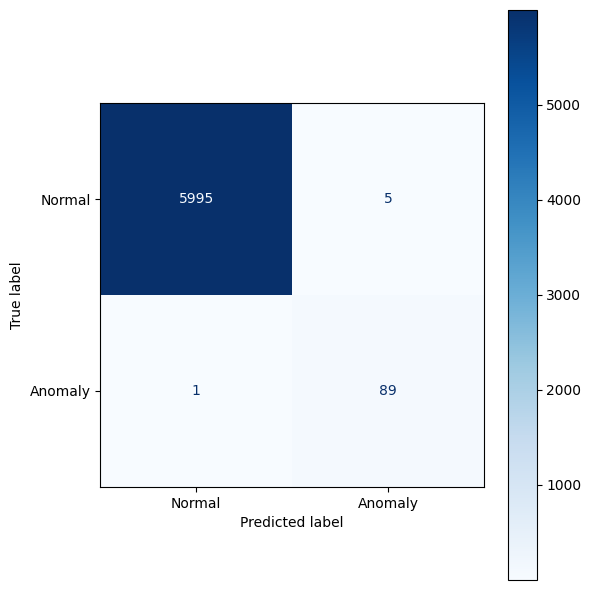

Saved: confusion_matrix_AS-SRDT.png


In [3]:
print("\n==================== TEST RESULTS ====================")
print(f"AUROC: {auroc:.4f}")
print(f"Binary F1 (anomaly=1): {f1_bin:.4f}")
print(f"MCC: {mcc:.4f}")
print("Threshold t (from q* on normal TEST scores):", best_q)
print("\nClassification report:")
print(classification_report(y_true_te, y_pred_te, digits=4, zero_division=0))

cm = confusion_matrix(y_true_te, y_pred_te)
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])

fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax_cm, cmap="Blues", colorbar=True)
plt.title("")
plt.tight_layout()
plt.savefig("confusion_matrix_AS-SRDT.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_AS-SRDT.png")

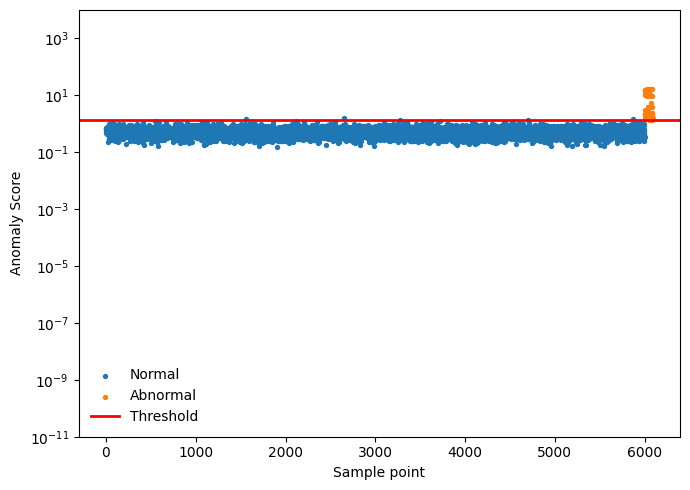

Saved: MonitoringChart_AS_SRDT.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

def plot_monitoring_chart_colored(scores, labels, thr, title, out_png,
                                  s_norm=8, s_anom=8):
    scores = np.asarray(scores).reshape(-1)
    labels = np.asarray(labels).reshape(-1).astype(int)
    assert scores.shape[0] == labels.shape[0]

    x = np.arange(len(scores))
    mask_norm = (labels == 0)
    mask_anom = (labels == 1)

    # epsilon shift để tránh 0 trên log-scale
    eps = 1e-6
    scores_plot = np.maximum(scores, eps)
    thr_plot = max(thr, eps)

    plt.figure(figsize=(7, 5))

    plt.scatter(x[mask_norm], scores_plot[mask_norm], s=s_norm, label="Normal")
    plt.scatter(x[mask_anom], scores_plot[mask_anom], s=s_anom, label="Abnormal")
    plt.axhline(thr_plot, linewidth=2, color="red", label="Threshold")

    plt.yscale("log")
    plt.ylim(1e-11, 1e4)   # <<< QUAN TRỌNG

    ax = plt.gca()
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())

    plt.xlabel("Sample point")
    plt.ylabel("Anomaly Score")
    plt.title(title)
    plt.legend(loc="lower left", frameon=False)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_png}")


# --- Plot Deep SAD (colored) ---
plot_monitoring_chart_colored(
    scores=s_all_te,          # <-- anomaly scores (TEST)
    labels=y_true_te,         # <-- ground-truth labels (TEST)
    thr=best_t,               # <-- threshold from q*
    title="",
    out_png="MonitoringChart_AS_SRDT.png"
)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

f_best.eval()

# ===== 1. NORMAL scores (train) =====
with torch.no_grad():
    z_n = f_best(Xn_tr.to(device))
    scores_normal = (z_n.norm(dim=1) / sigma_n).cpu().numpy()

# ===== 2. ANOMALY scores (train) =====
with torch.no_grad():
    z_a = f_best(Xa_tr.to(device))
    scores_anomaly = (z_a.norm(dim=1) / sigma_n).cpu().numpy()

# ===== 3. INTERMEDIATE scores (train) =====
# Sinh intermediate từ ALL normal × ALL anomaly (đúng Algorithm 1–2 của bạn)
with torch.no_grad():
    xmid_tr, _, _ = generate_intermediate_allpairs_filtered_with_indices(
        xb_n=Xn_tr.to(device),
        Xa_all=Xa_tr.to(device),
        knn_n=knn_n,
        knn_a=knn_a,
        w=best_cfg["w"],
        k1=best_cfg["k1"],
        k2=best_cfg["k2"],
    )

    z_m = f_best(xmid_tr)
    scores_intermediate = (z_m.norm(dim=1) / sigma_n).cpu().numpy()

print(
    f"Normal: {len(scores_normal)}, "
    f"Intermediate: {len(scores_intermediate)}, "
    f"Anomaly: {len(scores_anomaly)}"
)




Normal: 800, Intermediate: 5116, Anomaly: 9


In [6]:
# ===============================
# GLOBAL AXIS (dùng cho TẤT CẢ FIG)
# ===============================

all_scores = np.concatenate([
    scores_normal,
    scores_anomaly,
    scores_intermediate,      # nếu DeepSAD thì bỏ
])

GLOBAL_X_MIN = float(np.min(all_scores))
GLOBAL_X_MAX = float(np.max(all_scores))

print("GLOBAL X:", GLOBAL_X_MIN, GLOBAL_X_MAX)


GLOBAL X: 0.16257058084011078 16.171676635742188


800
9
5116


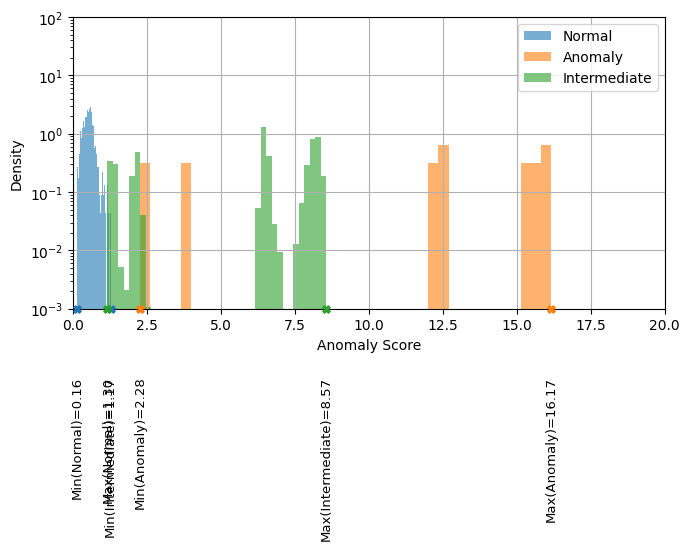

Saved: AS-SRDT_train_anomaly_score_histogram_labeled_minmax.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Giả sử đã có:
# scores_normal, scores_anomaly, scores_intermediate

# --- Tính min / max ---
n_min, n_max = float(np.min(scores_normal)), float(np.max(scores_normal))
a_min, a_max = float(np.min(scores_anomaly)), float(np.max(scores_anomaly))
m_min, m_max = float(np.min(scores_intermediate)), float(np.max(scores_intermediate))

print(len(scores_normal))
print(len(scores_anomaly))
print(len(scores_intermediate))

plt.figure(figsize=(7, 6))

# =====================================================
# GIỮ Y HỆT HÌNH CŨ: hist + legend + log-scale
# =====================================================

# Histogram (giữ nguyên)
plt.hist(scores_normal, bins=40, density=True, alpha=0.6, label="Normal")
plt.hist(scores_anomaly, bins=40, density=True, alpha=0.6, label="Anomaly")
plt.hist(scores_intermediate, bins=40, density=True, alpha=0.6, label="Intermediate")

# --- Log-scale & axis (đặt trước để nhất quán) ---
plt.yscale("log")
plt.ylim(1e-3, 1e2)      # log-scale không nhận 0
plt.xlim(0, 20)

# =====================================================
# MARKER X (log-scale: KHÔNG dùng y=0)
# =====================================================
y_marker = 1e-3

plt.scatter([n_min, n_max], [y_marker, y_marker],
            s=30, marker="X", linewidths=0.8, zorder=10, clip_on=False)

plt.scatter([a_min, a_max], [y_marker, y_marker],
            s=30, marker="X", linewidths=0.8, zorder=10, clip_on=False)

plt.scatter([m_min, m_max], [y_marker, y_marker],
            s=30, marker="X", linewidths=0.8, zorder=10, clip_on=False)

# =====================================================
# TEXT DƯỚI TRỤC X (KHÔNG đè lên hình, an toàn log-scale)
# =====================================================
ax = plt.gca()
y_offset = -0.23   # chỉnh -0.18 ~ -0.30 tùy bạn muốn gần/xa trục

ax.text(n_min, y_offset, f"Min(Normal)={n_min:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(n_max-0.1, y_offset, f"Max(Normal)={n_max:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(m_min+0.1, y_offset, f"Min(Intermediate)={m_min:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(m_max, y_offset, f"Max(Intermediate)={m_max:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(a_min, y_offset, f"Min(Anomaly)={a_min:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(a_max, y_offset, f"Max(Anomaly)={a_max:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)
plt.grid(True)
# --- Style (KHÔNG lưới) ---
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.savefig("AS-SRDT_train_anomaly_score_histogram_labeled_minmax.png",
            dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.show()

print("Saved: AS-SRDT_train_anomaly_score_histogram_labeled_minmax.png")
